In [1]:
!pip -q install -U datasets evaluate seqeval transformers accelerate sentencepiece huggingface_hub
!pip -q install -U natasha slovnet razdel
!pip -q install -U gliner
!pip -q install -U scikit-learn seaborn matplotlib
!pip -q install -U optimum onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 113.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 16.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2

In [2]:
import os, re, math, random, gc

import numpy as np
import pandas as pd

import torch
from torch import nn
import torch.nn.functional as F

from datasets import load_dataset, DatasetDict
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    pipeline
)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

from natasha import Doc, Segmenter, NewsEmbedding, NewsNERTagger
from razdel import sentenize

from gliner import GLiNER

from huggingface_hub import login
from google.colab import userdata

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### NER

**Named Entity Recognition - распознавание именованных сущностей**


Имена людей, названия организаций, книг, городов, и другие имена собственные называют «именованные сущности» (named entities), а саму задачу — «распознавание именованных сущностей». По-английски «Named entity recognition» или коротко NER; это сокращение регулярно используется и в русскоязычных текстах.

За одной задачей NER, на самом деле, стоит две: 1) обнаружить, что какая-то последовательность слов — это именованная сущность; 2) понять, к какому классу (имя человека, название организации, город и т.п.) эта именованная сущность относится. На каждом из этапов возникают свои сложности.

### Подходы

#### Sequence Labeling

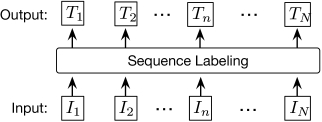

#### BIO-разметка

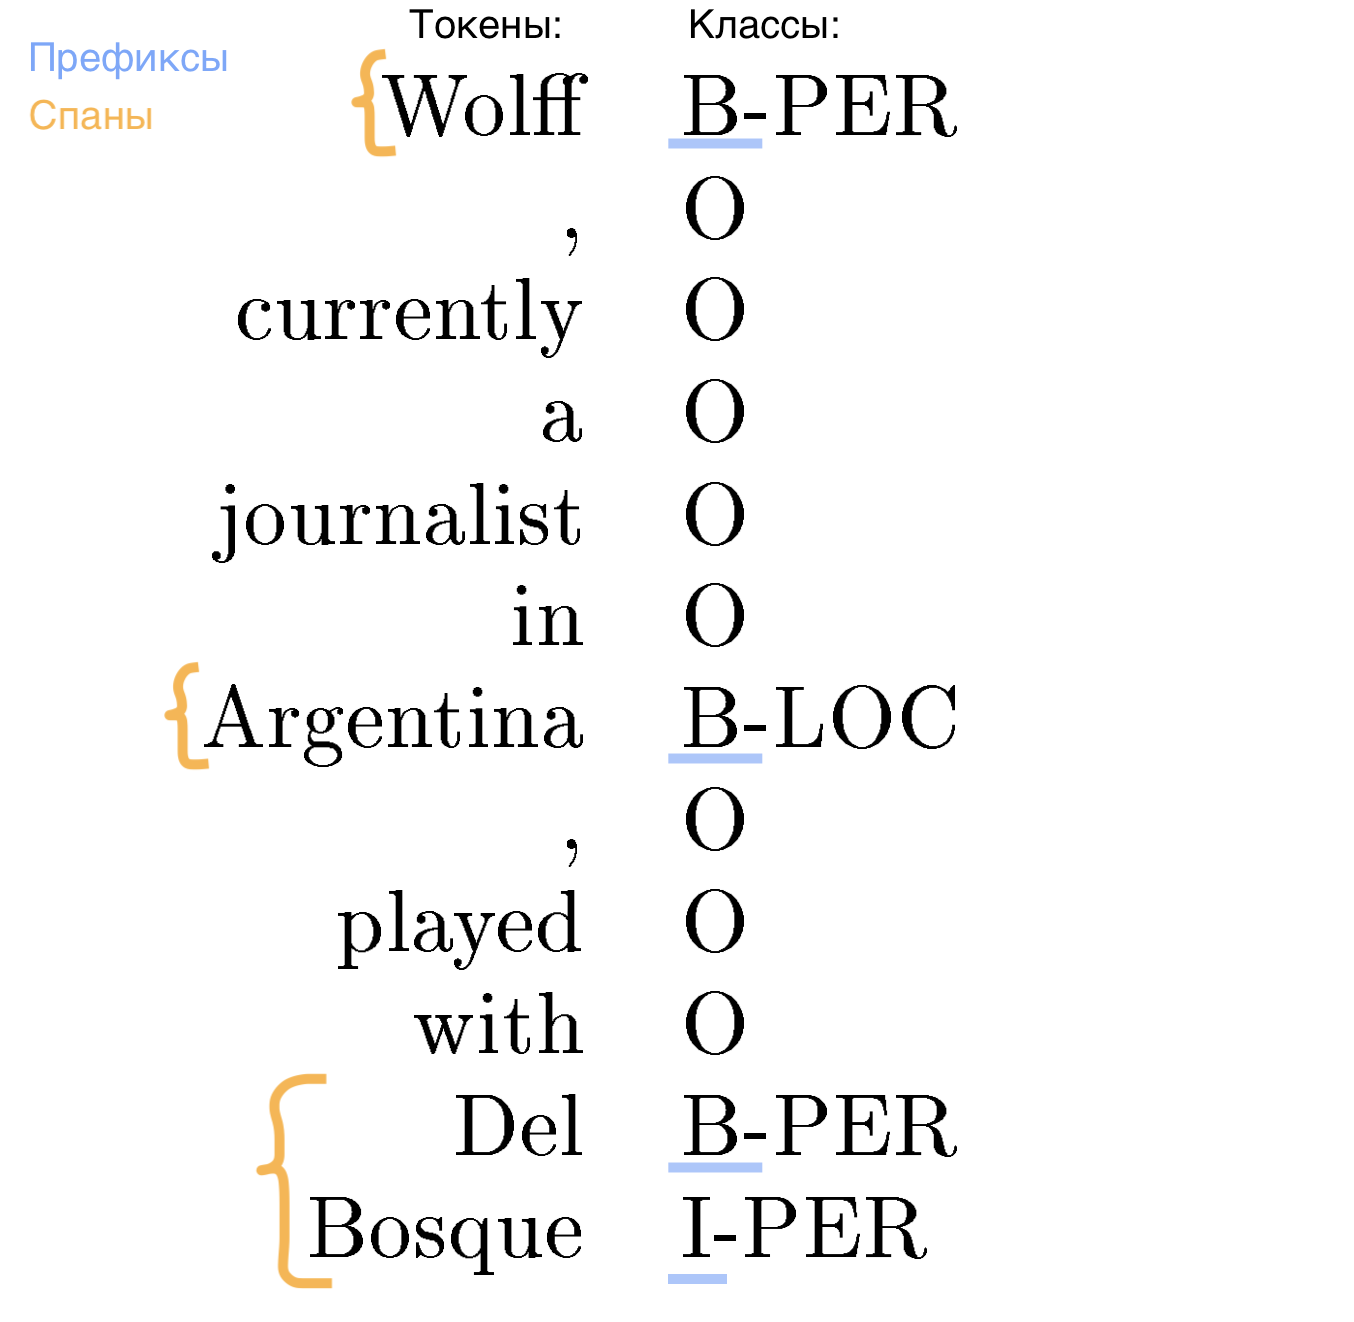

Что еще можно считать сущностью?

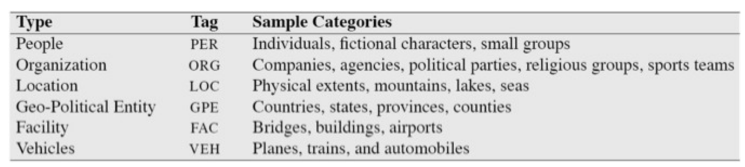

#### CNN + BiLSTM + CRF


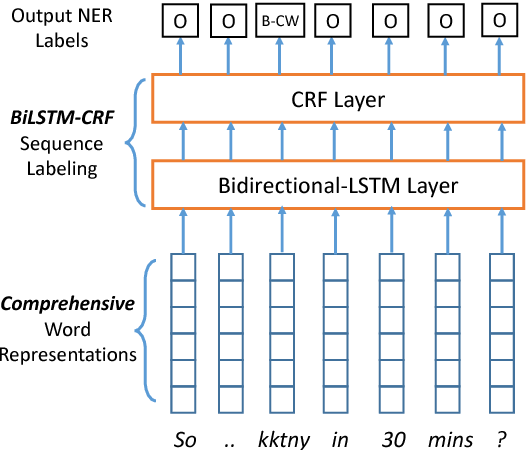


[End-to-end Sequence Labeling via Bi-directional LSTM-CNNs-CRF](https://arxiv.org/pdf/1603.01354.pdf)


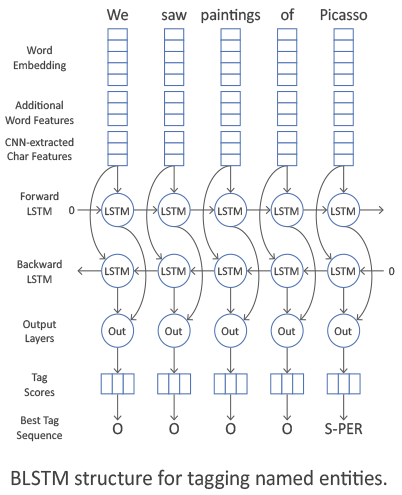

[An Introduction to Conditional Random Fields
](https://arxiv.org/pdf/1011.4088.pdf)

#### Transformers

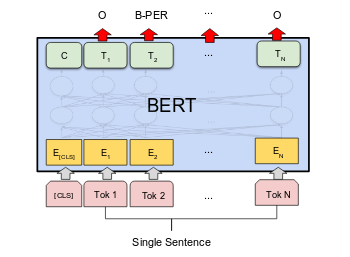

### Загрузка данных

[WikiANN](https://huggingface.co/datasets/unimelb-nlp/wikiann) -  is a multilingual named entity recognition dataset consisting of Wikipedia articles annotated with LOC (location), PER (person), and ORG (organisation) tags in the IOB2 format. This version corresponds to the balanced train, dev, and test splits of Rahimi et al. (2019), which supports 176 of the 282 languages from the original WikiANN corpus.

In [4]:
ds = load_dataset("wikiann", "ru")
ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

ru/validation-00000-of-00001.parquet:   0%|          | 0.00/809k [00:00<?, ?B/s]

ru/test-00000-of-00001.parquet:   0%|          | 0.00/816k [00:00<?, ?B/s]

ru/train-00000-of-00001.parquet:   0%|          | 0.00/1.63M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

DatasetDict({
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 10000
    })
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 20000
    })
})

In [5]:
ds["train"].features

{'tokens': List(Value('string')),
 'ner_tags': List(ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'])),
 'langs': List(Value('string')),
 'spans': List(Value('string'))}

In [6]:
label_names = ds["train"].features["ner_tags"].feature.names
label_names

['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']

In [7]:
train_size = 20000
val_size = 2000
test_size = 2000

ds_small = DatasetDict({
    "train": ds["train"].shuffle(seed=SEED).select(range(train_size)),
    "validation": ds["validation"].shuffle(seed=SEED).select(range(val_size)),
    "test": ds["test"].shuffle(seed=SEED).select(range(test_size)),
})
ds_small

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 20000
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 2000
    })
})

### Подготовка данных

In [8]:
def normalize_text(s):
    s = s.replace("\u00ad", "") # soft hyphen
    s = s.replace("\u200b", "") # zero-width space
    s = re.sub(r"\s+", " ", s).strip()
    return s

In [9]:
def tokens_to_text_and_offsets(tokens):
    # Собираем текст как " ".join(tokens) и считаем char offsets каждого токена
    parts = []
    offsets = []
    cur = 0
    for i, t in enumerate(tokens):
        if i > 0:
            parts.append(" ")
            cur += 1
        start = cur
        parts.append(t)
        cur += len(t)
        end = cur
        offsets.append((start, end))
    text = "".join(parts)
    text = normalize_text(text)
    return text, offsets

In [10]:
def bio_to_spans(labels):
    spans = []
    start = None
    ent_type = None

    for i, lab in enumerate(labels):
        if lab == "O":
            if ent_type is not None:
                spans.append((start, i, ent_type))
                start, ent_type = None, None
            continue

        prefix, typ = lab.split("-", 1)
        if prefix == "B":
            if ent_type is not None:
                spans.append((start, i, ent_type))
            start, ent_type = i, typ
        elif prefix == "I":
            if ent_type is None:
                # некорректная последовательность: считаем как B
                start, ent_type = i, typ
            elif typ != ent_type:
                spans.append((start, i, ent_type))
                start, ent_type = i, typ

    if ent_type is not None:
        spans.append((start, len(labels), ent_type))
    return spans

In [11]:
def spans_char_from_bio(tokens, offsets, labels):
    # label-спаны в токенах - char-спаны
    spans = bio_to_spans(labels)
    char_spans = []
    for s, e, t in spans:
        cs = offsets[s][0]
        ce = offsets[e-1][1]
        char_spans.append((cs, ce, t))
    return char_spans

In [12]:
def char_spans_to_bio(tokens, offsets, char_spans, label_set=("PER","ORG","LOC")):
    # Строгое отображение: токен должен полностью лежать внутри char-span.
    # Если span обрезает токен - это будет boundary error!
    labels = ["O"] * len(tokens)

    # сортировка по start, длиннее раньше (на случай вложенности)
    char_spans = sorted(char_spans, key=lambda x: (x[0], -(x[1]-x[0])))

    for (cs, ce, typ) in char_spans:
        if typ not in label_set:
            continue
        covered = []
        for i, (ts, te) in enumerate(offsets):
            if ts >= cs and te <= ce:
                covered.append(i)
        if not covered:
            continue
        labels[covered[0]] = "B-" + typ
        for i in covered[1:]:
            labels[i] = "I-" + typ

    return labels

### Утилиты для оценки качества

In [13]:
seqeval_metric = evaluate.load("seqeval")

def seqeval_strict_micro_f1(y_true, y_pred):
    # evaluate/seqeval дает entity-level строгое совпадение спана
    # В res есть overall_f1/precision/recall
    res = seqeval_metric.compute(predictions=y_pred, references=y_true, zero_division=0)
    return res

In [14]:
def boundary_error_breakdown(y_true, y_pred):
    # Анализ по спанам: exact, type_confusion, boundary_mismatch, missing, spurious
    stats = {
        "exact": 0,
        "type_confusion": 0,
        "boundary_mismatch": 0,
        "missing": 0,
        "spurious": 0,
        "total_gold": 0,
        "total_pred": 0,
    }

    for gt, pr in zip(y_true, y_pred):
        gsp = bio_to_spans(gt)
        psp = bio_to_spans(pr)

        stats["total_gold"] += len(gsp)
        stats["total_pred"] += len(psp)

        gset = {(s, e, t) for (s, e,  t) in gsp}
        pset = {(s, e, t) for (s, e, t) in psp}

        # Точные совпадения - одинаковые start, end и type
        exact = gset & pset
        stats["exact"] += len(exact)

        # Те же границы, разный тип
        gb = {(s, e): t for (s, e, t) in gsp}
        pb = {(s, e): t for (s, e, t) in psp}
        for b in set(gb.keys()) & set(pb.keys()):
            if gb[b] != pb[b]:
                stats["type_confusion"] += 1

        # boundary mismatch - есть пересечение по токенам, но точного совпадения по границам нет
        def overlaps(a, b):
            (s1, e1, _t1) = a
            (s2, e2, _t2) = b
            return max(s1, s2) < min(e1, e2)

        # Для каждой gold-сущности, которая не попала в exact:
        # если она пересекается хотя бы с одним предсказанным спаном, это boundary_mismatch
        # если не пересекается ни с одним, это missing
        for g in gsp:
            if g in exact:
                continue
            if any(overlaps(g, p) for p in psp):
                stats["boundary_mismatch"] += 1
            else:
                stats["missing"] += 1

        # Для каждой предсказанной сущности, которая не попала в exact:
        # если она не пересекается ни с одной gold-сущностью, это spurious
        # если пересекается, ничего не добавляется, потому что boundary_mismatch
        # уже считают только по gold-стороне, чтобы не удваивать счётчик
        for p in psp:
            if p in exact:
                continue
            if any(overlaps(p, g) for g in gsp):
                pass
            else:
                stats["spurious"] += 1

    return stats

In [15]:
def confusion_matrix_by_type(y_true, y_pred, entity_types=("PER","ORG","LOC")):
    # Матрица только по exact boundary matches + type confusion (по одинаковым границам)
    # Классы: entity_types
    labels = list(entity_types)
    idx = {t:i for i,t in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=int)

    for gt, pr in zip(y_true, y_pred):
        gsp = bio_to_spans(gt)
        psp = bio_to_spans(pr)
        gb = {(s,e): t for (s,e,t) in gsp}
        pb = {(s,e): t for (s,e,t) in psp}
        for b in set(gb.keys()) & set(pb.keys()):
            g = gb[b]
            p = pb[b]
            if g in idx and p in idx:
                cm[idx[g], idx[p]] += 1

    return cm, labels

def plot_confusion(cm, labels, title):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("pred")
    plt.ylabel("gold")
    plt.show()

### Бейзлайны

#### Natasha

`В 2020 году в проекте Natasha нам удалось вплотную приблизится по качеству к DeepPavlov BERT NER, размер модели получился в 75 раз меньше (27МБ), потребление памяти в 30 раз меньше (205МБ), скорость в 2 раза больше на CPU (25 статей в секунду).`

[slovnet repo](https://github.com/natasha/slovnet#ner)

Natasha (Slovnet NER) = Slovnet BERT NER — аналог DeepPavlov BERT NER + дистилляция через синтетическую разметку (Nerus) в WordCNN-CRF c квантованными эмбеддингами (Navec) + движок для инференса на NumPy.

[Подробнее об обучении](https://natasha.github.io/ner/)

In [16]:
segmenter = Segmenter()
emb = NewsEmbedding()
ner_tagger = NewsNERTagger(emb)

def natasha_ner_char_spans(text):
    doc = Doc(text)
    doc.segment(segmenter)
    doc.tag_ner(ner_tagger)
    spans = []
    for s in doc.spans:
        # Natasha типы: PER/LOC/ORG (обычно так), но встречается MISC
        spans.append((s.start, s.stop, s.type))
    return spans

In [19]:
ENTITY_TYPES = ("PER","ORG","LOC")

def wikiann_example_to_labels(example):
    tokens = example["tokens"]
    gold = [label_names[i] for i in example["ner_tags"]]
    return tokens, gold

def run_natasha_on_dataset(ds_split, limit=None):
    y_true = []
    y_pred = []

    n = len(ds_split) if limit is None else min(limit, len(ds_split))
    for i in range(n):
        ex = ds_split[i]
        tokens, gold = wikiann_example_to_labels(ex)
        text, offsets = tokens_to_text_and_offsets(tokens)

        spans = natasha_ner_char_spans(text)
        pred = char_spans_to_bio(tokens, offsets, spans, label_set=ENTITY_TYPES)

        y_true.append(gold)
        y_pred.append(pred)

    return y_true, y_pred

y_true_nat, y_pred_nat = run_natasha_on_dataset(ds_small["test"], limit=1000)
res_nat = seqeval_strict_micro_f1(y_true_nat, y_pred_nat)
res_nat

{'LOC': {'precision': np.float64(0.603448275862069),
  'recall': np.float64(0.6984478935698448),
  'f1': np.float64(0.6474820143884892),
  'number': np.int64(451)},
 'ORG': {'precision': np.float64(0.6010928961748634),
  'recall': np.float64(0.25943396226415094),
  'f1': np.float64(0.3624382207578254),
  'number': np.int64(424)},
 'PER': {'precision': np.float64(0.16598360655737704),
  'recall': np.float64(0.22562674094707522),
  'f1': np.float64(0.1912632821723731),
  'number': np.int64(359)},
 'overall_precision': np.float64(0.42414082145850796),
 'overall_recall': np.float64(0.4100486223662885),
 'overall_f1': np.float64(0.4169756901524516),
 'overall_accuracy': 0.7162595952547104}

In [20]:
boundary_nat = boundary_error_breakdown(y_true_nat, y_pred_nat)
boundary_nat

{'exact': 506,
 'type_confusion': 83,
 'boundary_mismatch': 506,
 'missing': 222,
 'spurious': 33,
 'total_gold': 1234,
 'total_pred': 1193}

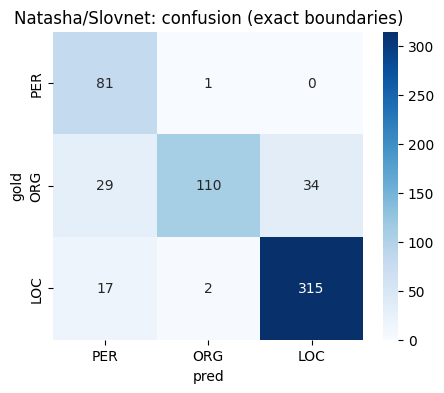

In [21]:
cm_nat, cm_labels = confusion_matrix_by_type(y_true_nat, y_pred_nat, entity_types=ENTITY_TYPES)
plot_confusion(cm_nat, cm_labels, "Natasha/Slovnet: confusion (exact boundaries)")

#### GLiNER

Семейство GLiNER для open-type NER: модель умеет извлекать сущности по пользовательским меткам, а не только по фиксированному набору классов, и делает это с помощью bidirectional transformer encoder.

Идея GLiNER в том, что типы сущностей тоже подаются как вход, поэтому модель не привязана к заранее зашитому списку вроде PER/ORG/LOC и может работать в zero-shot стиле для новых label names!

На вход идут entity type prompts и сам текст, модель строит представления токенов/слов, представления спанов и представления типов сущностей, а затем считает матрицу сходства между спанами и типами через dot product и sigmoid

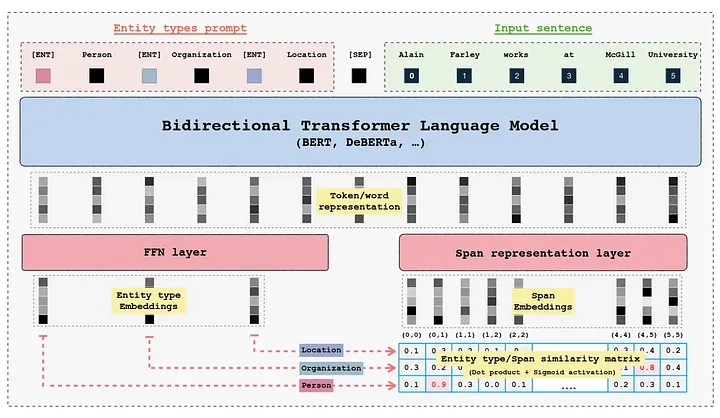

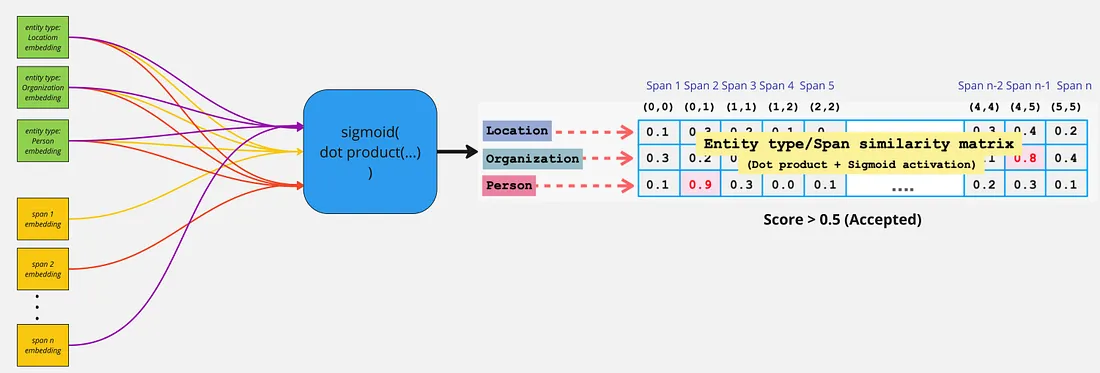

- Backbone для модели - microsoft/mdeberta-v3-base - мультиязычная версия DeBERTa V3, использующая ту же архитектурную идею, что и DeBERTa, но обученная на multilingual корпусе CC100.

- У base-версии 12 transformer-слоев, hidden size 768, 12 attention heads и большой multilingual vocabulary на 250K токенов.


- Ключевая идея семейства DeBERTa — disentangled attention: модель раздельно учитывает содержимое токена и его позиционную информацию, вместо того чтобы просто сложить token embedding и positional embedding на входе, как в более классических BERT-подобных схемах.


В V3 предобучение было изменено на ELECTRA-style Replaced Token Detection

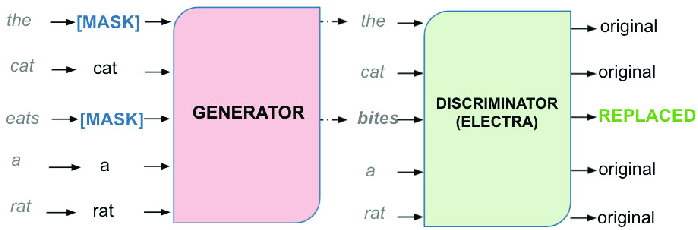


In [22]:
gliner_model_id = "urchade/gliner_multi-v2.1"
gliner = GLiNER.from_pretrained(gliner_model_id).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:186: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

In [23]:
def gliner_char_spans(text, labels=("person","organization","location"), threshold=0.35):
    # GLiNER ожидает текст и список label-слов (в zero-shot стиле)
    ents = gliner.predict_entities(text, labels=list(labels), threshold=threshold)
    out = []
    for e in ents:
        lab = e["label"].lower()
        if lab.startswith("person"):
            t = "PER"
        elif lab.startswith("organization"):
            t = "ORG"
        elif lab.startswith("location"):
            t = "LOC"
        else:
            continue
        out.append((e["start"], e["end"], t))
    return out

In [25]:
def run_gliner_on_dataset(ds_split, limit=None, threshold=0.35):
    y_true, y_pred = [], []
    n = len(ds_split) if limit is None else min(limit, len(ds_split))

    for i in range(n):
        ex = ds_split[i]
        tokens, gold = wikiann_example_to_labels(ex)
        text, offsets = tokens_to_text_and_offsets(tokens)

        spans = gliner_char_spans(text, threshold=threshold)

        pred = char_spans_to_bio(tokens, offsets, spans, label_set=ENTITY_TYPES)
        y_true.append(gold)
        y_pred.append(pred)

    return y_true, y_pred

y_true_g, y_pred_g = run_gliner_on_dataset(ds_small["test"], limit=1000, threshold=0.35)
seqeval_strict_micro_f1(y_true_g, y_pred_g)

{'LOC': {'precision': np.float64(0.42857142857142855),
  'recall': np.float64(0.738359201773836),
  'f1': np.float64(0.5423452768729642),
  'number': np.int64(451)},
 'ORG': {'precision': np.float64(0.5329153605015674),
  'recall': np.float64(0.4009433962264151),
  'f1': np.float64(0.4576043068640646),
  'number': np.int64(424)},
 'PER': {'precision': np.float64(0.16764132553606237),
  'recall': np.float64(0.2395543175487465),
  'f1': np.float64(0.19724770642201836),
  'number': np.int64(359)},
 'overall_precision': np.float64(0.3660658794282163),
 'overall_recall': np.float64(0.4773095623987034),
 'overall_f1': np.float64(0.4143510376362997),
 'overall_accuracy': 0.7246336357292393}

In [26]:
boundary_g = boundary_error_breakdown(y_true_g, y_pred_g)
boundary_g

{'exact': 589,
 'type_confusion': 101,
 'boundary_mismatch': 532,
 'missing': 113,
 'spurious': 179,
 'total_gold': 1234,
 'total_pred': 1609}

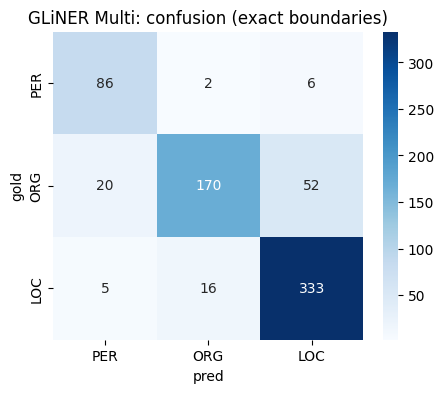

In [27]:
cm_g, cm_labels = confusion_matrix_by_type(y_true_g, y_pred_g, entity_types=ENTITY_TYPES)
plot_confusion(cm_g, cm_labels, "GLiNER Multi: confusion (exact boundaries)")

#### Результаты бейзлайнов

In [40]:
def summarize(name, y_true, y_pred):
    res = seqeval_strict_micro_f1(y_true, y_pred)
    b = boundary_error_breakdown(y_true, y_pred)
    return {
        "model": name,
        "f1": res["overall_f1"],
        "precision": res["overall_precision"],
        "recall": res["overall_recall"],
        "exact_spans": b["exact"],
        "type_confusion": b["type_confusion"],
        "boundary_mismatch": b["boundary_mismatch"],
        "missing": b["missing"],
        "spurious": b["spurious"],
        "gold_spans": b["total_gold"],
        "pred_spans": b["total_pred"],
    }

rows = []
rows.append(summarize("Natasha/Slovnet", y_true_nat, y_pred_nat))
rows.append(summarize("GLiNER Multi", y_true_g, y_pred_g))
rows

[{'model': 'Natasha/Slovnet',
  'f1': np.float64(0.4169756901524516),
  'precision': np.float64(0.42414082145850796),
  'recall': np.float64(0.4100486223662885),
  'exact_spans': 506,
  'type_confusion': 83,
  'boundary_mismatch': 506,
  'missing': 222,
  'spurious': 33,
  'gold_spans': 1234,
  'pred_spans': 1193},
 {'model': 'GLiNER Multi',
  'f1': np.float64(0.4143510376362997),
  'precision': np.float64(0.3660658794282163),
  'recall': np.float64(0.4773095623987034),
  'exact_spans': 589,
  'type_confusion': 101,
  'boundary_mismatch': 532,
  'missing': 113,
  'spurious': 179,
  'gold_spans': 1234,
  'pred_spans': 1609}]

In [41]:
pd.DataFrame(rows)

,model,f1,precision,recall,exact_spans,type_confusion,boundary_mismatch,missing,spurious,gold_spans,pred_spans
0,Natasha/Slovnet,0.416976,0.424141,0.410049,506,83,506,222,33,1234,1193
1,GLiNER Multi,0.414351,0.366066,0.477310,589,101,532,113,179,1234,1609


In [42]:
del gliner
gc.collect()

22690

### Дообучим модель

#### Что там еще у bert'ов?

##### NeoBERT

- RoPE
- Pre-LN RMSNorm, SwiGLU
- Классический Multi-Head Attention
- Flash attention
- 28 слоев при той же размерности вектора (768)
- MLM pretraining
- masking rate подняли до 20%
- дообучение во вторую стадию на длинном контексте



##### ModernBERT

- Контекст – 8к токенов
- Rotary Positional Embeddings – RoPE
- Flash attention и unpadding для оптимизации
- Global + Sliding window attention (каждый третий слой — global attention, остальные — local sliding-window)
- 22 и 28 слоев, для base- и large- версий
- размерность hidden size - 768
- masking rate подняли до 30%
- дообучение во вторую стадию на длинном контексте



#### deepvk/RuModernBERT-base

In [43]:
model_id = "deepvk/RuModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)

id2label = {i: l for i, l in enumerate(label_names)}
label2id = {l: i for i, l in enumerate(label_names)}

config.json: 0.00B [00:00, ?B/s]

The `reference_compile` argument is deprecated and will be removed in `transformers v5.2.0`Use `torch.compile()` directly on the model instead.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/837 [00:00<?, ?B/s]

In [44]:
def tokenize_and_align_labels(examples, max_length=256):
    tokenized = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=max_length
    )

    aligned_labels = []
    for i in range(len(examples["tokens"])):
        word_ids = tokenized.word_ids(batch_index=i)
        gold = examples["ner_tags"][i]
        prev = None
        out = []
        for w in word_ids:
            if w is None:
                out.append(-100)
            elif w != prev:
                out.append(gold[w])
            else:
                # стандартно: продолжения слова игнорируем
                out.append(-100)
            prev = w
        aligned_labels.append(out)

    tokenized["labels"] = aligned_labels
    return tokenized

max_length = 192
tokenized = ds_small.map(lambda x: tokenize_and_align_labels(x, max_length=max_length), batched=True)
tokenized

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 20000
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 2000
    })
})

In [45]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    y_true, y_pred = [], []
    for p, l in zip(preds, labels):
        true_labels = []
        pred_labels = []
        for pi, li in zip(p, l):
            if li == -100:
                continue
            true_labels.append(id2label[li])
            pred_labels.append(id2label[pi])
        y_true.append(true_labels)
        y_pred.append(pred_labels)

    res = seqeval_metric.compute(predictions=y_pred, references=y_true, zero_division=0)
    return {
        "f1": res["overall_f1"],
        "precision": res["overall_precision"],
        "recall": res["overall_recall"],
    }

In [46]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer, padding="longest")

model = AutoModelForTokenClassification.from_pretrained(
    model_id,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id
)

# Freeze encoder на быстрый разогрев головы
for p in model.base_model.parameters():
    p.requires_grad = False

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForTokenClassification LOAD REPORT from: deepvk/RuModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [47]:
args = TrainingArguments(
    output_dir="rumodernbert_ner",
    learning_rate=5e-4, # голова обучается быстро
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    num_train_epochs=10,
    fp16=True, # https://developer.nvidia.com/blog/video-mixed-precision-techniques-tensor-cores-deep-learning/
    eval_strategy="steps",
    save_strategy="steps",
    logging_steps=50,
    eval_steps=200,
    save_steps=200,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

trainer_warmup = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

trainer_warmup.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Step,Training Loss,Validation Loss,F1,Precision,Recall
200,1.076732,0.532015,0.494058,0.428193,0.583868
400,0.984901,0.488411,0.523227,0.449438,0.626003
600,0.949293,0.469554,0.520477,0.457056,0.604334
800,0.972382,0.454294,0.543555,0.486375,0.615971
1000,0.830482,0.452290,0.549720,0.487578,0.630016
1200,0.868158,0.429584,0.559898,0.513740,0.615169
1400,0.843302,0.425141,0.568860,0.515309,0.634831
1600,0.861239,0.433844,0.547856,0.478430,0.640851
1800,0.829053,0.439908,0.577940,0.529569,0.636035
2000,0.810725,0.421257,0.557787,0.497173,0.635233


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3200, training_loss=0.9037672007083892, metrics={'train_runtime': 641.6532, 'train_samples_per_second': 311.695, 'train_steps_per_second': 9.74, 'total_flos': 2703751657843968.0, 'train_loss': 0.9037672007083892, 'epoch': 5.12})

In [48]:
# Unfreeze для полноценного дообучения
for p in model.base_model.parameters():
    p.requires_grad = True

args2 = TrainingArguments(
    output_dir="rumodernbert_ner_ft",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    num_train_epochs=10,
    fp16=True,
    eval_strategy="steps",
    save_strategy="steps",
    logging_steps=50,
    eval_steps=200,
    save_steps=200,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    warmup_ratio=0.1,
    weight_decay=0.01,
    max_grad_norm=1.0
)

trainer = Trainer(
    model=model,
    args=args2,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,F1,Precision,Recall
200,0.586582,0.277233,0.718762,0.678546,0.764045
400,0.470127,0.220384,0.786728,0.753490,0.823034
600,0.427466,0.189480,0.819099,0.793233,0.846709
800,0.328185,0.197015,0.833889,0.815497,0.853130
1000,0.254498,0.176504,0.855336,0.842679,0.868379
1200,0.270265,0.152803,0.862629,0.851172,0.874398
1400,0.165842,0.186218,0.860979,0.847589,0.874799
1600,0.157070,0.188151,0.861702,0.846362,0.877608
1800,0.160367,0.171521,0.875964,0.863831,0.888443
2000,0.063271,0.232744,0.865637,0.844334,0.888042


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2400, training_loss=0.27193624248107273, metrics={'train_runtime': 1543.3862, 'train_samples_per_second': 129.585, 'train_steps_per_second': 4.05, 'total_flos': 2030369515816896.0, 'train_loss': 0.27193624248107273, 'epoch': 3.84})

In [49]:
preds = trainer.predict(tokenized["test"])
test_metrics = preds.metrics
test_metrics

{'test_loss': 0.20329706370830536,
 'test_f1': 0.8518218623481781,
 'test_precision': 0.8372463191404695,
 'test_recall': 0.8669138854552946,
 'test_runtime': 3.6318,
 'test_samples_per_second': 550.695,
 'test_steps_per_second': 17.347}

In [50]:
def trainer_predictions_to_seqeval(pred_output):
    logits = pred_output.predictions
    labels = pred_output.label_ids
    preds = np.argmax(logits, axis=-1)

    y_true, y_pred = [], []
    for p, l in zip(preds, labels):
        true_labels = []
        pred_labels = []
        for pi, li in zip(p, l):
            if li == -100:
                continue
            true_labels.append(id2label[li])
            pred_labels.append(id2label[pi])
        y_true.append(true_labels)
        y_pred.append(pred_labels)
    return y_true, y_pred

y_true_ft, y_pred_ft = trainer_predictions_to_seqeval(preds)

seqeval_strict_micro_f1(y_true_ft, y_pred_ft), boundary_error_breakdown(y_true_ft, y_pred_ft)

({'LOC': {'precision': np.float64(0.8219735503560529),
   'recall': np.float64(0.9048152295632699),
   'f1': np.float64(0.8614072494669509),
   'number': np.int64(893)},
  'ORG': {'precision': np.float64(0.784409257003654),
   'recall': np.float64(0.7703349282296651),
   'f1': np.float64(0.7773083886541942),
   'number': np.int64(836)},
  'PER': {'precision': np.float64(0.919605077574048),
   'recall': np.float64(0.9340974212034384),
   'f1': np.float64(0.9267945984363894),
   'number': np.int64(698)},
  'overall_precision': np.float64(0.8372463191404695),
  'overall_recall': np.float64(0.8669138854552946),
  'overall_f1': np.float64(0.8518218623481781),
  'overall_accuracy': 0.9520485796049417},
 {'exact': 2104,
  'type_confusion': 115,
  'boundary_mismatch': 270,
  'missing': 53,
  'spurious': 48,
  'total_gold': 2427,
  'total_pred': 2513})

In [52]:
boundary_ft_small = boundary_error_breakdown(y_true_ft, y_pred_ft)
boundary_ft_small

{'exact': 2104,
 'type_confusion': 115,
 'boundary_mismatch': 270,
 'missing': 53,
 'spurious': 48,
 'total_gold': 2427,
 'total_pred': 2513}

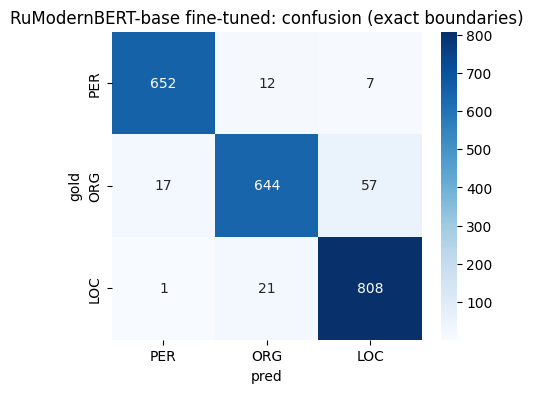

In [51]:
cm_ft_small, cm_labels_small = confusion_matrix_by_type(y_true_ft, y_pred_ft, entity_types=ENTITY_TYPES)
plot_confusion(cm_ft_small, cm_labels_small, "RuModernBERT-small fine-tuned: confusion (exact boundaries)")

In [54]:
rows.append(summarize("RuModernBERT-base", y_true_ft, y_pred_ft))

In [55]:
pd.DataFrame(rows)

,model,f1,precision,recall,exact_spans,type_confusion,boundary_mismatch,missing,spurious,gold_spans,pred_spans
0,Natasha/Slovnet,0.416976,0.424141,0.410049,506,83,506,222,33,1234,1193
1,GLiNER Multi,0.414351,0.366066,0.477310,589,101,532,113,179,1234,1609
2,RuModernBERT-base,0.851822,0.837246,0.866914,2104,115,270,53,48,2427,2513


In [60]:
login(token=userdata.get("HF_WRITE"))

In [61]:
trainer.push_to_hub(commit_message="RuModernBERT-base ner finetuned")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ..._ner_ft/model.safetensors:   0%|          |  554kB /  598MB            

  ..._ner_ft/training_args.bin:   6%|6         |   326B / 5.20kB            

CommitInfo(commit_url='https://huggingface.co/masterkristall/rumodernbert_ner_ft/commit/df8e67880c216f1d77fa2b73d2a64ebbd48f65a5', commit_message='RuModernBERT-base ner finetuned', commit_description='', oid='df8e67880c216f1d77fa2b73d2a64ebbd48f65a5', pr_url=None, repo_url=RepoUrl('https://huggingface.co/masterkristall/rumodernbert_ner_ft', endpoint='https://huggingface.co', repo_type='model', repo_id='masterkristall/rumodernbert_ner_ft'), pr_revision=None, pr_num=None)

#### deepvk/RuModernBERT-small as-is

In [62]:
small_model_id = "deepvk/RuModernBERT-small"
tokenizer = AutoTokenizer.from_pretrained(model_id)

id2label = {i: l for i, l in enumerate(label_names)}
label2id = {l: i for i, l in enumerate(label_names)}

In [63]:
small_model = AutoModelForTokenClassification.from_pretrained(
    small_model_id,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/138M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

ModernBertForTokenClassification LOAD REPORT from: deepvk/RuModernBERT-small
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [64]:
args = TrainingArguments(
    output_dir="rumodernbert_ner_ft_small",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    num_train_epochs=10,
    fp16=True,
    eval_strategy="steps",
    save_strategy="steps",
    logging_steps=50,
    eval_steps=200,
    save_steps=200,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    warmup_ratio=0.1,
    weight_decay=0.01,
    max_grad_norm=1.0
)

trainer_small = Trainer(
    model=small_model,
    args=args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

trainer_small.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Step,Training Loss,Validation Loss,F1,Precision,Recall
200,1.390612,0.605682,0.439292,0.383969,0.513242
400,0.811044,0.356139,0.626927,0.583477,0.677368
600,0.634993,0.300835,0.721299,0.681170,0.766453
800,0.499243,0.263315,0.780285,0.769922,0.790931
1000,0.382290,0.229960,0.808427,0.793583,0.823836
1200,0.399475,0.216193,0.800873,0.791765,0.810193
1400,0.286013,0.219465,0.810907,0.798754,0.823435
1600,0.283292,0.206523,0.814031,0.795481,0.833467
1800,0.266049,0.237366,0.814537,0.802023,0.827448
2000,0.146585,0.269308,0.807857,0.783774,0.833467


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3000, training_loss=0.6067674357891083, metrics={'train_runtime': 501.5106, 'train_samples_per_second': 398.795, 'train_steps_per_second': 12.462, 'total_flos': 348070495264800.0, 'train_loss': 0.6067674357891083, 'epoch': 4.8})

In [65]:
preds = trainer_small.predict(tokenized["test"])
test_metrics = preds.metrics
test_metrics

{'test_loss': 0.24878934025764465,
 'test_f1': 0.8028112449799196,
 'test_precision': 0.7830003916960439,
 'test_recall': 0.8236505974454058,
 'test_runtime': 1.8224,
 'test_samples_per_second': 1097.426,
 'test_steps_per_second': 34.569}

In [66]:
y_true_ft_small, y_pred_ft_small = trainer_predictions_to_seqeval(preds)

seqeval_strict_micro_f1(y_true_ft_small, y_pred_ft_small)
boundary_error_breakdown(y_true_ft_small, y_pred_ft_small)

{'exact': 1999,
 'type_confusion': 151,
 'boundary_mismatch': 360,
 'missing': 68,
 'spurious': 94,
 'total_gold': 2427,
 'total_pred': 2553}

In [67]:
rows.append(summarize("RuModernBERT-small", y_true_ft_small, y_pred_ft_small))

In [68]:
pd.DataFrame(rows)

,model,f1,precision,recall,exact_spans,type_confusion,boundary_mismatch,missing,spurious,gold_spans,pred_spans
0,Natasha/Slovnet,0.416976,0.424141,0.410049,506,83,506,222,33,1234,1193
1,GLiNER Multi,0.414351,0.366066,0.477310,589,101,532,113,179,1234,1609
2,RuModernBERT-base,0.851822,0.837246,0.866914,2104,115,270,53,48,2427,2513
3,RuModernBERT-small,0.802811,0.783000,0.823651,1999,151,360,68,94,2427,2553


In [69]:
trainer_small.push_to_hub(commit_message="RuModernBERT-small ner finetuned")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...t_small/model.safetensors:   1%|          | 1.11MB /  138MB            

  ...t_small/training_args.bin:  95%|#########4| 4.92kB / 5.20kB            

CommitInfo(commit_url='https://huggingface.co/masterkristall/rumodernbert_ner_ft_small/commit/eb035e02a7f00a1d86b19b0972ee9325aab7da2b', commit_message='RuModernBERT-small ner finetuned', commit_description='', oid='eb035e02a7f00a1d86b19b0972ee9325aab7da2b', pr_url=None, repo_url=RepoUrl('https://huggingface.co/masterkristall/rumodernbert_ner_ft_small', endpoint='https://huggingface.co', repo_type='model', repo_id='masterkristall/rumodernbert_ner_ft_small'), pr_revision=None, pr_num=None)

In [72]:
del trainer_small, small_model
gc.collect()

2474